In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib
import pandas as pd
import numpy as np
import scipy.sparse

SAVE_PATH = '/content/drive/MyDrive/co2_project/'

# Load all normal files
df_clean     = pd.read_csv(SAVE_PATH + 'df_clean.csv')
X_train      = pd.read_csv(SAVE_PATH + 'X_train.csv')
X_test       = pd.read_csv(SAVE_PATH + 'X_test.csv')
y_train      = pd.read_csv(SAVE_PATH + 'y_train.csv').squeeze()
y_test       = pd.read_csv(SAVE_PATH + 'y_test.csv').squeeze()
preprocessor = joblib.load(SAVE_PATH + 'preprocessor.joblib')

print("✅ All CSV files loaded!")

# ── Rebuild X_preprocessed directly ──────────────────────
# Combine train + test to get full dataset
X_all = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

# Transform using loaded preprocessor
X_preprocessed = preprocessor.transform(X_all).toarray()

print("✅ X_preprocessed rebuilt! Shape:", X_preprocessed.shape)

# Save it so you never have to rebuild again
scipy.sparse.save_npz(
    SAVE_PATH + 'X_preprocessed.npz',
    scipy.sparse.csr_matrix(X_preprocessed)
)
print("✅ X_preprocessed saved to Drive for next time!")

✅ All CSV files loaded!
✅ X_preprocessed rebuilt! Shape: (35638, 61)
✅ X_preprocessed saved to Drive for next time!


In [ ]:
# Neural networks need preprocessed numpy arrays, not raw dataframes
X_train_preprocessed = preprocessor.transform(X_train).toarray()
X_test_preprocessed  = preprocessor.transform(X_test).toarray()

y_train_arr = y_train.values
y_test_arr  = y_test.values

print("X_train_preprocessed shape:", X_train_preprocessed.shape)
print("X_test_preprocessed shape :", X_test_preprocessed.shape)

X_train_preprocessed shape: (28510, 61)
X_test_preprocessed shape : (7128, 61)


In [ ]:
!pip install tensorflow --quiet
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, r2_score

# ── Build ANN Model ──────────────────────────────────────
ann_model = keras.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),           # prevents overfitting
    layers.Dense(64,  activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1)                # output layer — single CO2 value
], name="ANN_Model")

ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

ann_model.summary()

# ── Train ANN ────────────────────────────────────────────
print("\nTraining ANN...")
ann_history = ann_model.fit(
    X_train_preprocessed, y_train_arr,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ── Evaluate ANN ─────────────────────────────────────────
y_pred_ann = ann_model.predict(X_test_preprocessed).flatten()
mse_ann    = mean_squared_error(y_test_arr, y_pred_ann)
r2_ann     = r2_score(y_test_arr, y_pred_ann)

print(f"\nANN Results:")
print(f"  MSE       : {mse_ann:.2f}")
print(f"  R-squared : {r2_ann:.4f}")

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,305 (71.50 KB)

 Trainable params: 18,305 (71.50 KB)

 Non-trainable params: 0 (0.00 B)


Training ANN...
Epoch 1/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 5996.0693 - mae: 14.5958 - val_loss: 5943.3384 - val_mae: 12.7035
Epoch 2/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3010.5544 - mae: 11.5405 - val_loss: 3882.4802 - val_mae: 12.0297
Epoch 3/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1620.8369 - mae: 9.3261 - val_loss: 1607.8751 - val_mae: 8.2387
Epoch 4/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 849.0856 - mae: 7.7434 - val_loss: 675.4564 - val_mae: 6.1003
Epoch 5/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 652.7352 - mae: 7.2309 - val_loss: 514.6810 - val_mae: 5.6006
Epoch 6/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 552.4617 - mae: 6.6991 - val_loss: 405.8225 - val_mae: 4.9376
Epoch 7/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 494.7780 - mae: 6.3222 - val_loss: 395.1385 - val_mae: 5.0161
Epoch 8/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 415.7108 - mae: 6.0288 - val_loss: 589.7263 - val_mae: 5.70

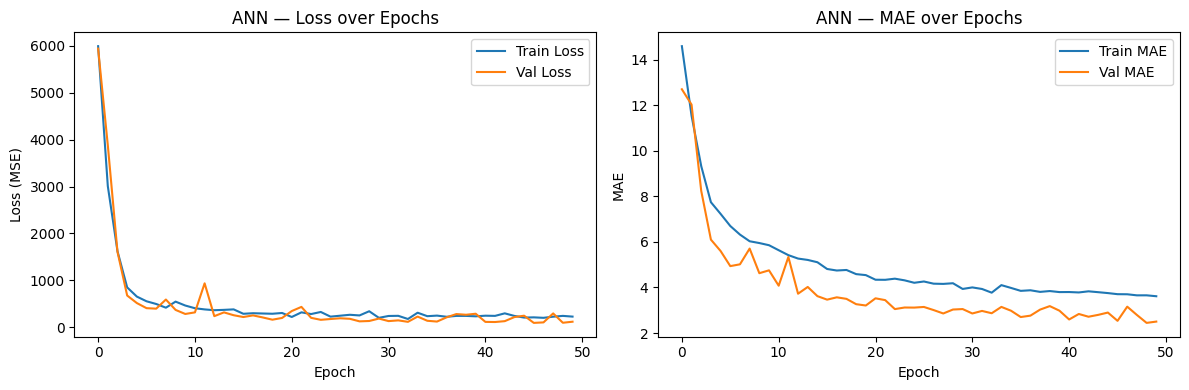

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(ann_history.history['loss'],     label='Train Loss')
plt.plot(ann_history.history['val_loss'], label='Val Loss')
plt.title('ANN — Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(ann_history.history['mae'],     label='Train MAE')
plt.plot(ann_history.history['val_mae'], label='Val MAE')
plt.title('ANN — MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

RNN


In [ ]:
# RNN needs 3D input: (samples, timesteps, features)
# We treat each feature as one timestep
# So shape goes from (samples, features) → (samples, features, 1)

X_train_rnn = X_train_preprocessed.reshape(
    X_train_preprocessed.shape[0],   # number of samples
    X_train_preprocessed.shape[1],   # timesteps (= number of features)
    1                                  # 1 value per timestep
)

X_test_rnn = X_test_preprocessed.reshape(
    X_test_preprocessed.shape[0],
    X_test_preprocessed.shape[1],
    1
)

print("X_train_rnn shape:", X_train_rnn.shape)
print("X_test_rnn shape :", X_test_rnn.shape)
print("✅ Data reshaped for RNN!")

X_train_rnn shape: (28510, 61, 1)
X_test_rnn shape : (7128, 61, 1)
✅ Data reshaped for RNN!


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, r2_score

# ── Build RNN Model ──────────────────────────────────────
rnn_model = keras.Sequential([
    layers.Input(shape=(X_train_rnn.shape[1], 1)),

    # First RNN layer
    layers.SimpleRNN(64, return_sequences=True),
    layers.Dropout(0.2),

    # Second RNN layer
    layers.SimpleRNN(32, return_sequences=False),
    layers.Dropout(0.2),

    # Dense output layers
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
], name="RNN_Model")

rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

rnn_model.summary()

# ── Train RNN ────────────────────────────────────────────
print("\nTraining RNN...")
rnn_history = rnn_model.fit(
    X_train_rnn, y_train_arr,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ── Evaluate RNN ─────────────────────────────────────────
y_pred_rnn = rnn_model.predict(X_test_rnn).flatten()
mse_rnn    = mean_squared_error(y_test_arr, y_pred_rnn)
r2_rnn     = r2_score(y_test_arr, y_pred_rnn)

print(f"\nRNN Results:")
print(f"  MSE       : {mse_rnn:.2f}")
print(f"  R-squared : {r2_rnn:.4f}")

Model: "RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 61, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)


Training RNN...
Epoch 1/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 7479.7266 - mae: 18.1107 - val_loss: 11042.2109 - val_mae: 22.3601
Epoch 2/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 7473.6519 - mae: 19.9672 - val_loss: 11050.3418 - val_mae: 21.2325
Epoch 3/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 7462.4468 - mae: 20.3578 - val_loss: 11041.9580 - val_mae: 22.3762
Epoch 4/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - loss: 7461.3042 - mae: 20.4867 - val_loss: 11057.2168 - val_mae: 21.3250
Epoch 5/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - loss: 7457.9102 - mae: 20.4893 - val_loss: 11036.2822 - val_mae: 23.4485
Epoch 6/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - loss: 7463.4902 - mae: 20.6635 - val_loss: 11048.3105 - val_mae: 21.9593
Epoch 7/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 7458.5239 - mae: 20.4765 - val_loss: 11029.9785 - val_mae: 24.0837
Epoch 8/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - loss: 7462.0029 - mae: 2

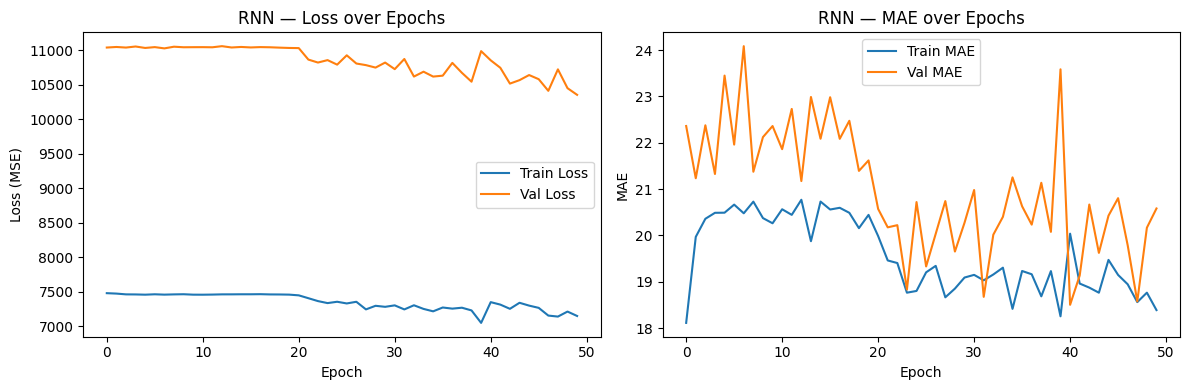

In [ ]:
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['loss'],     label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Val Loss')
plt.title('RNN — Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['mae'],     label='Train MAE')
plt.plot(rnn_history.history['val_mae'], label='Val MAE')
plt.title('RNN — MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Compare ANN vs RNN
nn_comparison = pd.DataFrame({
    'Model'             : ['ANN', 'RNN'],
    'MSE'               : [round(mse_ann, 2), round(mse_rnn, 2)],
    'R-squared'         : [round(r2_ann,  4), round(r2_rnn,  4)],
})

print("=== ANN vs RNN Comparison ===")
print(nn_comparison.to_string(index=False))
print("\n📌 Lower MSE = Better")
print("📌 Higher R-squared = Better (max is 1.0)")

=== ANN vs RNN Comparison ===
Model     MSE  R-squared
  ANN  175.87     0.9777
  RNN 7411.66     0.0614

📌 Lower MSE = Better
📌 Higher R-squared = Better (max is 1.0)


In [ ]:
import joblib

# Save ANN model
ann_model.save(SAVE_PATH + 'ann_model.keras')
print("✅ ANN model saved!")

# Save RNN model
rnn_model.save(SAVE_PATH + 'rnn_model.keras')
print("✅ RNN model saved!")

# Save results for final comparison notebook
nn_results = {
    'mse_ann' : mse_ann,
    'r2_ann'  : r2_ann,
    'mse_rnn' : mse_rnn,
    'r2_rnn'  : r2_rnn,
}
joblib.dump(nn_results, SAVE_PATH + 'nn_results.joblib')
print("✅ Results saved for final comparison!")

✅ ANN model saved!
✅ RNN model saved!
✅ Results saved for final comparison!


=== FINAL MODEL COMPARISON (All Models) ===
                 Model      MSE  R-squared
1  Decision Tree (ID3)    39.48     0.9950
2                  KNN    50.82     0.9936
3                  ANN   175.87     0.9777
4                  SVM  7082.76     0.1030
5                  RNN  7411.66     0.0614


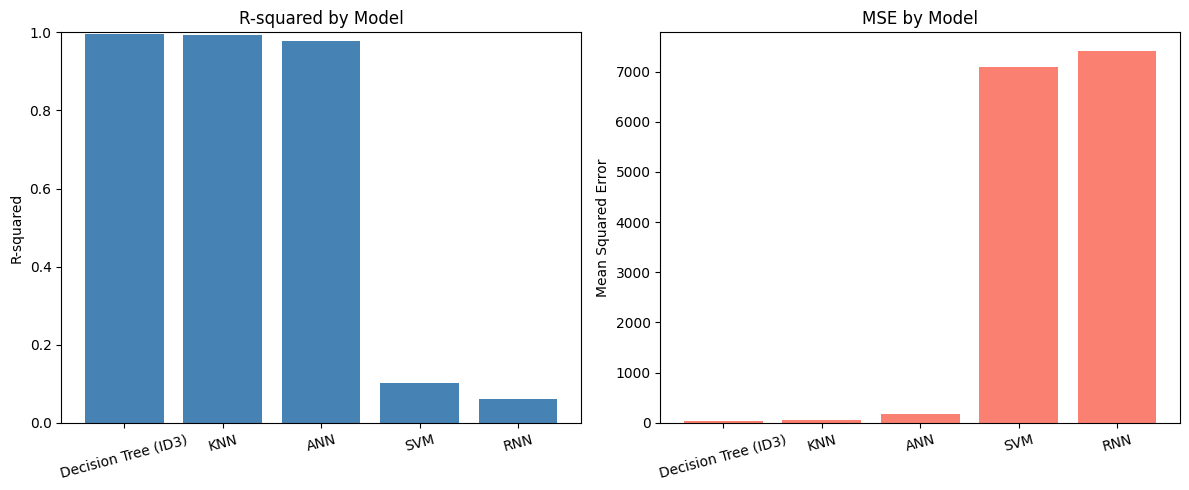

In [ ]:
# Load ML model results from Notebook 2
# ⚠️ You need to save these in Notebook 2 first — see note below
ml_results = joblib.load(SAVE_PATH + 'ml_results.joblib')

# Build complete comparison table
all_models = pd.DataFrame({
    'Model' : [
        'KNN',
        'SVM',
        'Decision Tree (ID3)',
        'ANN',
        'RNN'
    ],
    'MSE' : [
        round(ml_results['mse_knn'], 2),
        round(ml_results['mse_svm'], 2),
        round(ml_results['mse_dt'],  2),
        round(mse_ann, 2),
        round(mse_rnn, 2),
    ],
    'R-squared' : [
        round(ml_results['r2_knn'], 4),
        round(ml_results['r2_svm'], 4),
        round(ml_results['r2_dt'],  4),
        round(r2_ann,  4),
        round(r2_rnn,  4),
    ]
})

# Sort by best R-squared
all_models = all_models.sort_values('R-squared', ascending=False).reset_index(drop=True)
all_models.index += 1  # start rank from 1

print("=== FINAL MODEL COMPARISON (All Models) ===")
print(all_models.to_string())

# Plot comparison
plt.figure(figsize=(12, 5))

# R-squared bar chart
plt.subplot(1, 2, 1)
plt.bar(all_models['Model'], all_models['R-squared'], color='steelblue')
plt.title('R-squared by Model')
plt.ylabel('R-squared')
plt.xticks(rotation=15)
plt.ylim(0, 1)

# MSE bar chart
plt.subplot(1, 2, 2)
plt.bar(all_models['Model'], all_models['MSE'], color='salmon')
plt.title('MSE by Model')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()